In [ ]:
get_ipython().system('pip install opencv-contrib-python numpy scikit-learn matplotlib')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 MB 5.3 MB/s eta 0:00:0000:0100:01


In [ ]:
import cv2
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

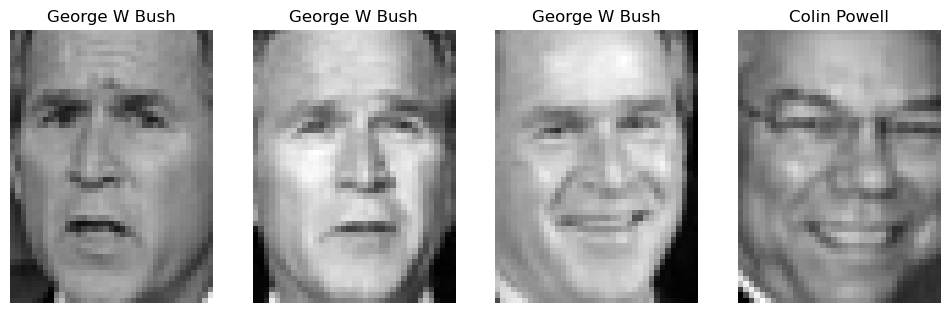

In [ ]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
faces = lfw_people.images
labels = lfw_people.target
label_names = lfw_people.target_names 

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(faces, labels_encoded, test_size=0.2, random_state=42)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    ax[i].imshow(X_train[i], cmap="gray")
    ax[i].set_title(label_names[y_train[i]])
    ax[i].axis("off")
plt.show()

In [ ]:
recognizer = cv2.face.LBPHFaceRecognizer_create()
train_imgs = []
train_labels = []

for i in range(len(X_train)):
    img = cv2.resize(X_train[i], (100, 100))
    train_imgs.append(img)
    train_labels.append(y_train[i])

recognizer.train(train_imgs, np.array(train_labels))

recognizer.save("face_model.yml")
np.save("label_dict.npy", label_encoder.classes_)

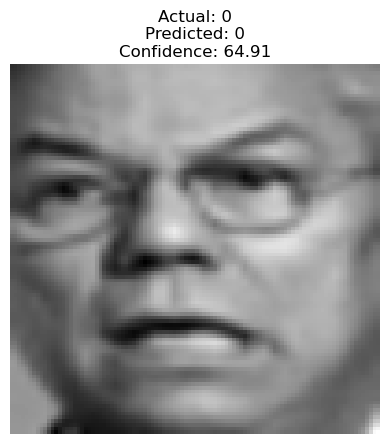

In [20]:
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("face_model.yml")

label_dict = np.load("label_dict.npy", allow_pickle=True)

test_img = X_test[0]
test_img_resized = cv2.resize(test_img, (100, 100))

actual_label = label_dict[y_test[0]]

label, confidence = recognizer.predict(test_img_resized)
predicted_name = label_dict[label]

plt.imshow(test_img_resized, cmap="gray")
plt.title(f"Actual: {actual_label}\nPredicted: {predicted_name}\nConfidence: {confidence:.2f}")
plt.axis("off")
plt.show()

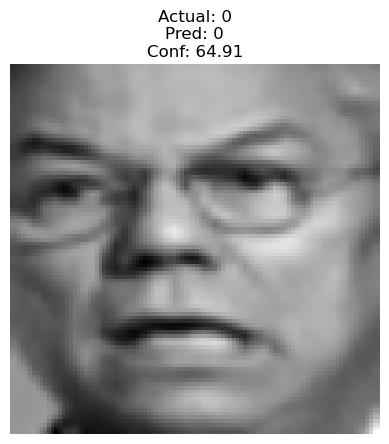

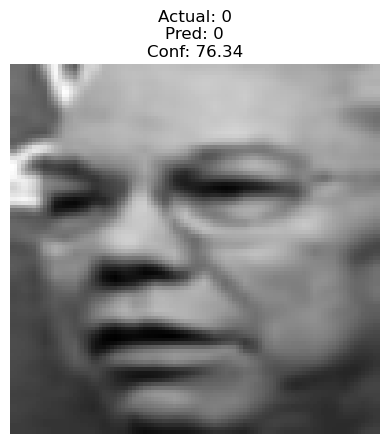

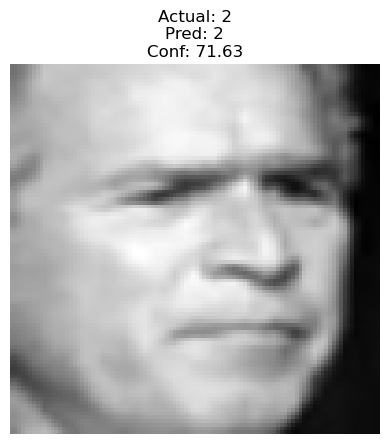

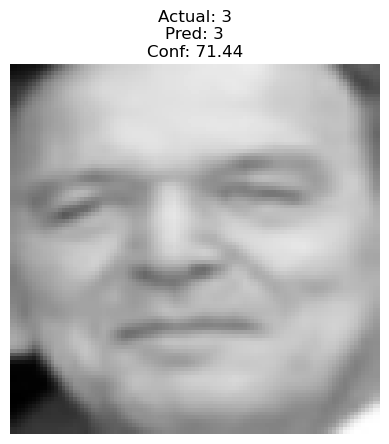

In [ ]:
num_tests = 4
for i in range(num_tests):
    test_img = X_test[i]
    test_img_resized = cv2.resize(test_img, (100, 100))

    actual_label = label_dict[y_test[i]]
    label, confidence = recognizer.predict(test_img_resized)
    predicted_name = label_dict[label]

    plt.imshow(test_img_resized, cmap="gray")
    plt.title(f"Actual: {actual_label}\nPred: {predicted_name}\nConf: {confidence:.2f}")
    plt.axis("off")
    plt.show()